# Advanced August 2026 forecasting

This notebook compares the locked baseline family, short-series statistical models, global county-panel regularized models, LightGBM, structural forecasts, and a fixed median ensemble. The targets are statewide **visits**, **pounds distributed**, and **individuals served** for August 2026.

Primary evaluation is rolling-origin August MAPE for 2023, 2024, and 2025. MAE, RMSE, median APE, WAPE, fold wins, and county-level metrics are supporting diagnostics. Scaling, imputation, and tuning occur inside each historical training cutoff.

In [1]:
from pathlib import Path
import subprocess
import sys
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd()
if cwd.name == 'forecast_august_2026':
    MODEL_DIR = cwd
elif (cwd / 'forecast_august_2026').exists():
    MODEL_DIR = cwd / 'forecast_august_2026'
else:
    MODEL_DIR = cwd / 'MINNEMUDAC_2026' / 'forecast_august_2026'
RESULTS_DIR = MODEL_DIR / 'advanced_results'
assert MODEL_DIR.exists(), MODEL_DIR
MODEL_DIR

WindowsPath('C:/Users/dinsa/OneDrive - UW-Madison/Documents/AA MINNEMUDAC/MINNEMUDAC_2026/forecast_august_2026')

## 1. Optional full rerun

Set `RUN_MODELS = True` to rebuild every feature, refit every inner time-ordered tuning fold, and overwrite the saved results. The supplied class notebooks are references for preprocessing and regularization; their random cross-validation examples are intentionally replaced here with chronological validation.

In [2]:
RUN_MODELS = False
if RUN_MODELS:
    subprocess.run(
        [sys.executable, str(MODEL_DIR / 'advanced_forecasting.py')],
        cwd=MODEL_DIR.parent,
        check=True,
    )
assert RESULTS_DIR.exists(), 'Run advanced_forecasting.py first.'

In [3]:
summary = pd.read_csv(RESULTS_DIR / 'statewide_model_summary.csv')
backtests = pd.read_csv(RESULTS_DIR / 'statewide_backtest_predictions.csv')
county_summary = pd.read_csv(RESULTS_DIR / 'county_model_summary.csv')
final = pd.read_csv(RESULTS_DIR / 'final_forecasts_all_models.csv')
coefficients = pd.read_csv(RESULTS_DIR / 'regularized_coefficients.csv')
importance = pd.read_csv(RESULTS_DIR / 'lightgbm_feature_importance.csv')
feature_audit = pd.read_csv(RESULTS_DIR / 'feature_eligibility_audit.csv')
source_audit = pd.read_csv(RESULTS_DIR / 'source_scope_audit.csv')

## 2. Feature eligibility and source scope

The advanced experiment uses the forecasting-pipeline clean export, which excludes meal-program rows. The earlier isolated baseline source includes those rows. All model comparisons below are apples-to-apples on the advanced clean series; do not mix the two target definitions in one leaderboard.

In [4]:
display(feature_audit)
display(source_audit[['locked_baseline_rows', 'advanced_clean_rows', 'rows_excluded_as_meal_programs', 'scope_note']].drop_duplicates())

,feature_group,status,reason
0,food-shelf lag and rolling features,primary,Computed with shift(1) or earlier within each ...
1,county and calendar month,primary,Known before the forecast month.
2,lagged reporting-site coverage,primary,Only prior-month counts are used; same-month c...
3,SNAP,sensitivity only,Conservative three-month availability lag used...
4,poverty and MMG,excluded,No consistent point-in-time history is availab...
5,"same-month outcomes, coverage, or flags",prohibited,Unknown at the July 31 cutoff and would leak t...


,locked_baseline_rows,advanced_clean_rows,rows_excluded_as_meal_programs,scope_note
0,28101,25399,2702,Advanced models use the forecasting_pipeline c...


## 3. Statewide model comparison

Lower values are better. `folds_better_than_naive` counts the August years in which a model's absolute percentage error is lower than seasonal naive. A primary challenger must have lower mean MAPE **and** win all three August folds.

,metric,model,folds,mape,median_ape,mae,rmse,wape,folds_better_than_naive,eligible_for_primary
0,individuals,ets,3,4.69,3.50,34135.0,40507.0,4.66,2,True
1,individuals,lasso_panel,3,6.28,6.94,46034.0,46650.0,6.29,1,True
2,individuals,core_median_ensemble,3,6.54,1.76,47530.0,73672.0,6.49,3,True
3,individuals,elastic_net_panel,3,6.95,6.73,50927.0,51160.0,6.96,1,True
4,individuals,structural_elastic_visits_x_ratio,3,7.21,4.69,52641.0,60983.0,7.19,1,True
5,individuals,sarima,3,8.39,8.81,61583.0,64559.0,8.41,1,True
6,individuals,robust_ensemble,3,9.40,10.24,69061.0,75029.0,9.43,1,True
7,individuals,ytd_growth,3,9.69,2.52,71951.0,107893.0,9.83,2,True
8,individuals,aug_jul_ratio,3,10.08,10.21,73714.0,86395.0,10.07,1,True
9,individuals,seasonal_naive,3,10.49,2.86,76369.0,110721.0,10.43,0,True


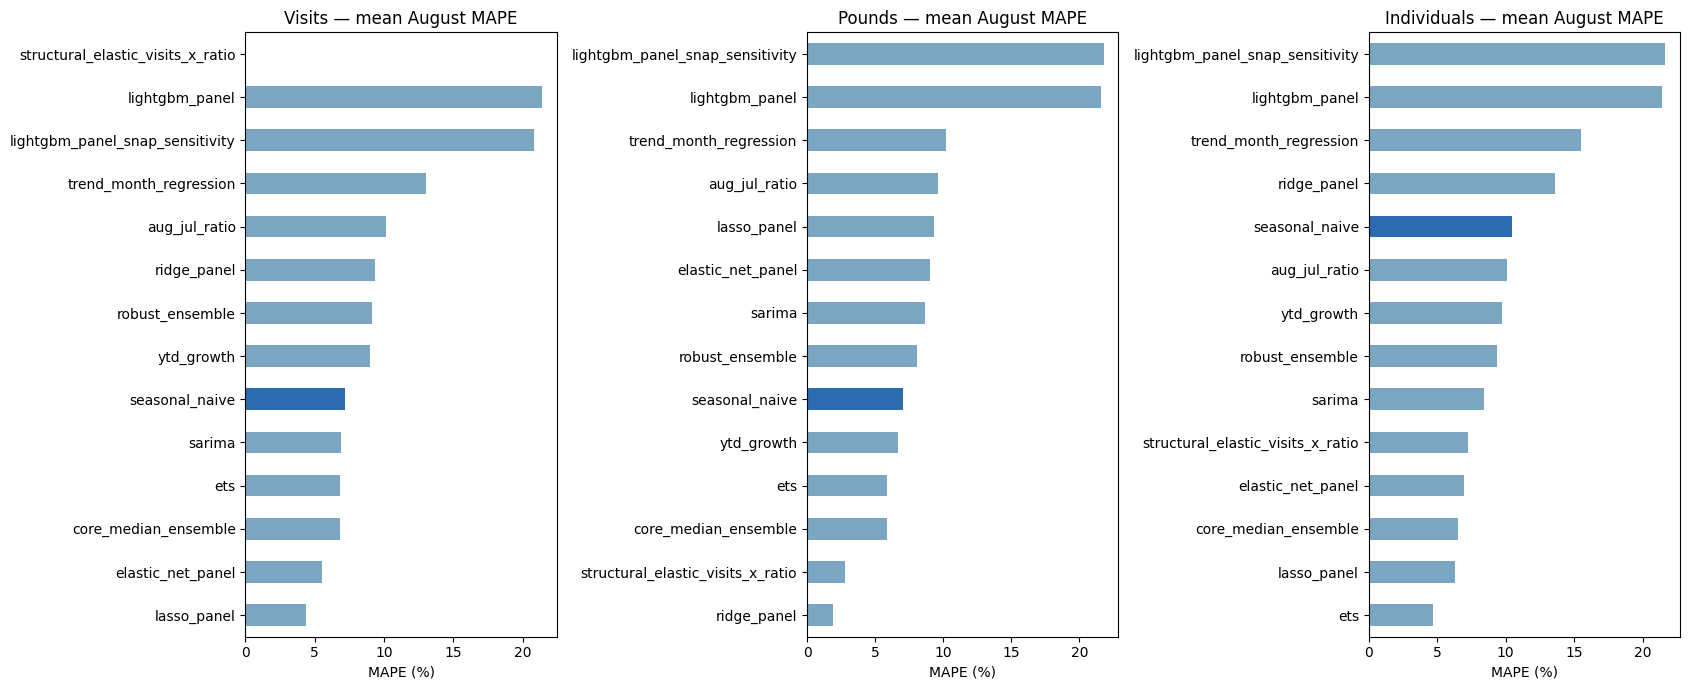

In [5]:
comparison = summary.copy()
for column in ['mape', 'median_ape', 'wape']:
    comparison[column] = 100 * comparison[column]
display(comparison.round({'mape': 2, 'median_ape': 2, 'wape': 2, 'mae': 0, 'rmse': 0}))

pivot = comparison.pivot(index='model', columns='metric', values='mape')
fig, axes = plt.subplots(1, 3, figsize=(17, 7), sharey=False)
for ax, metric in zip(axes, ['visits', 'pounds', 'individuals']):
    values = pivot[metric].sort_values()
    values.plot.barh(ax=ax, color=['#2b6cb0' if name == 'seasonal_naive' else '#7aa6c2' for name in values.index])
    ax.set_title(f'{metric.title()} — mean August MAPE')
    ax.set_xlabel('MAPE (%)')
    ax.set_ylabel('')
plt.tight_layout()

## 4. Inspect stability year by year

Average error alone can hide a model that wins because of one exceptional year. These rows expose the three independent August tests.

In [6]:
fold_view = backtests.copy()
fold_view['ape_percent'] = 100 * fold_view['absolute_percentage_error']
display(
    fold_view.pivot_table(
        index=['metric', 'model'], columns='forecast_year', values='ape_percent'
    ).round(2)
)

forecast_year                                   2023   2024   2025
metric      model                                                 
individuals aug_jul_ratio                       2.39  10.21  17.63
            core_median_ensemble               17.47   0.39   1.76
            elastic_net_panel                   6.73   7.74   6.38
            ets                                 8.83   1.73   3.50
            lasso_panel                         4.87   7.03   6.94
            lightgbm_panel                     32.32  20.17  11.78
            lightgbm_panel_snap_sensitivity    34.33  19.21  11.39
            ridge_panel                        12.18  22.03   6.60
            robust_ensemble                     4.25  13.71  10.24
            sarima                              5.07  11.29   8.81
            seasonal_naive                     26.12   2.51   2.86
            structural_elastic_visits_x_ratio  13.21   4.69   3.74
            trend_month_regression              6.10  17.20  23.10
            ytd_growth                          1.65  24.91   2.52
pounds      aug_jul_ratio                       2.32  14.34  12.21
            core_median_ensemble               14.96   1.14   1.41
            elastic_net_panel                  14.41  12.24   0.50
            ets                                12.68   1.66   3.32
            lasso_panel                        11.45  12.39   4.20
            lightgbm_panel                     30.18  19.64  14.94
            lightgbm_panel_snap_sensitivity    31.20  18.70  15.44
            ridge_panel                         2.18   3.40   0.23
            robust_ensemble                     3.80  12.77   7.72
            sarima                             23.78   2.11   0.17
            seasonal_naive                     17.25   0.61   3.23
            structural_elastic_visits_x_ratio   0.07   6.54   1.63
            trend_month_regression              4.87  11.19  14.53
            ytd_growth                          2.74  16.71   0.66
visits      aug_jul_ratio                       1.29   8.95  20.20
            core_median_ensemble               15.78   2.44   2.19
            elastic_net_panel                   9.83   1.87   4.87
            ets                                12.20   3.01   5.30
            lasso_panel                         6.74   1.11   5.27
            lightgbm_panel                     31.87  18.46  13.85
            lightgbm_panel_snap_sensitivity    32.23  17.27  12.94
            ridge_panel                        17.39   1.84   8.85
            robust_ensemble                     2.53  12.10  12.83
            sarima                              3.08   6.70  10.85
            seasonal_naive                     19.36   1.75   0.49
            trend_month_regression              3.78  15.24  20.11
            ytd_growth                          0.08  21.34   5.55

## 5. County-level diagnostics for panel models

County MAPE is not emphasized because small or zero county totals can make it unstable. WAPE, MAE, RMSE, sMAPE, and median APE are reported instead.

In [7]:
county_display = county_summary.copy()
for column in ['wape', 'smape', 'median_ape']:
    county_display[column] = 100 * county_display[column]
display(county_display.round({'wape': 2, 'smape': 2, 'median_ape': 2, 'mae': 1, 'rmse': 1}))

,metric,model,county_predictions,wape,mae,rmse,smape,median_ape
0,individuals,structural_elastic_visits_x_ratio,258,17.50,1489.9,5003.1,20.26,15.24
1,individuals,ridge_panel,258,19.07,1623.0,9366.0,17.40,13.02
2,individuals,elastic_net_panel,258,19.70,1676.6,7709.8,18.98,14.72
3,individuals,lasso_panel,258,20.47,1742.7,7741.9,18.93,15.43
4,individuals,lightgbm_panel,258,27.69,2356.8,15350.3,13.96,9.51
5,individuals,lightgbm_panel_snap_sensitivity,258,27.78,2364.2,15374.3,13.98,8.62
6,pounds,ridge_panel,258,13.02,19790.6,70409.8,17.99,12.99
7,pounds,structural_elastic_visits_x_ratio,258,23.83,36218.7,142633.3,28.11,20.29
8,pounds,elastic_net_panel,258,23.95,36404.9,224204.2,19.74,14.27
9,pounds,lasso_panel,258,24.15,36703.8,207119.1,19.55,14.43


## 6. August 2026 forecasts and selected hold values

The selected flag applies the conservative pre-committed rule. SNAP sensitivity forecasts are shown for comparison but cannot be selected.

In [8]:
display(final[['metric', 'model', 'forecast', 'selected', 'eligible_for_primary']])
display(final.loc[final['selected'], ['metric', 'model', 'forecast']].reset_index(drop=True))

,metric,model,forecast,selected,eligible_for_primary
0,visits,seasonal_naive,2.402800e+05,True,True
1,visits,ytd_growth,2.425204e+05,False,True
2,visits,aug_jul_ratio,2.555187e+05,False,True
3,visits,trend_month_regression,2.899872e+05,False,True
4,visits,robust_ensemble,2.490195e+05,False,True
5,visits,ets,2.413627e+05,False,True
6,visits,sarima,2.351536e+05,False,True
7,visits,ridge_panel,2.382548e+05,False,True
8,visits,lasso_panel,2.152840e+05,False,True
9,visits,elastic_net_panel,2.223778e+05,False,True


,metric,model,forecast
0,visits,seasonal_naive,2.402800e+05
1,pounds,seasonal_naive,1.282147e+07
2,individuals,core_median_ensemble,7.214098e+05


## 7. Regularization and LightGBM diagnostics

Standardized regularized coefficients are useful for interpretation, but correlated lags can redistribute weight across variables. LASSO zeros describe this fitted sample, not permanent variable truth. LightGBM split counts are also descriptive and should not override held-out performance.

In [9]:
top_regularized = coefficients.groupby(['metric', 'model'], group_keys=False).head(15)
top_lightgbm = importance.groupby(['metric', 'model'], group_keys=False).head(15)
display(top_regularized)
display(top_lightgbm)

,metric,model,feature,coefficient,absolute_coefficient,selected_nonzero
0,individuals,elastic_net_panel,categorical__fips_27053,-2.960118,2.960118,True
1,individuals,elastic_net_panel,categorical__fips_27073,-2.234367,2.234367,True
2,individuals,elastic_net_panel,categorical__fips_27109,2.041409,2.041409,True
3,individuals,elastic_net_panel,categorical__fips_27107,-2.003214,2.003214,True
4,individuals,elastic_net_panel,categorical__fips_27163,1.898471,1.898471,True
...,...,...,...,...,...,...
1002,visits,ridge_panel,categorical__fips_27137,1.735690,1.735690,True
1003,visits,ridge_panel,categorical__fips_27011,-1.721851,1.721851,True
1004,visits,ridge_panel,categorical__fips_27121,-1.717614,1.717614,True
1005,visits,ridge_panel,categorical__fips_27037,1.700556,1.700556,True


,metric,model,feature,split_importance
0,individuals,lightgbm_panel,numeric__individuals_lag_1,297
1,individuals,lightgbm_panel,numeric__individuals_rolling_mean_3,156
2,individuals,lightgbm_panel,numeric__month_cos,156
3,individuals,lightgbm_panel,numeric__visits_lag_1,140
4,individuals,lightgbm_panel,numeric__time_index,128
...,...,...,...,...
646,visits,lightgbm_panel_snap_sensitivity,numeric__snap_people_yoy,67
647,visits,lightgbm_panel_snap_sensitivity,numeric__visits_historical_month_ratio,65
648,visits,lightgbm_panel_snap_sensitivity,numeric__visits_rolling_mean_12,59
649,visits,lightgbm_panel_snap_sensitivity,numeric__time_index,53


## Interpretation

The data do not support a single universally best advanced model. LASSO has the lowest mean August MAPE for visits, Ridge for pounds, and ETS for individuals, but each loses to seasonal naive in at least one held-out August. Under the strict stability rule, seasonal naive remains selected for visits and pounds. The pre-specified core median ensemble beats seasonal naive in all three individual folds and is selected for individuals. LightGBM underperforms substantially, including with SNAP, so added nonlinear complexity is not justified here.

Only three August holdouts exist. Treat the selected forecasts as reproducible hold values until the official scoring rule and final target scope are confirmed.